## Error Estimation

How to estimate error for non-Gaussian distribution

In [1]:
import sys,os
import pandas as pd
import numpy as np

from scipy import stats
import math

import matplotlib.pyplot as plt
%config InlineBackend.figure_format = 'retina'

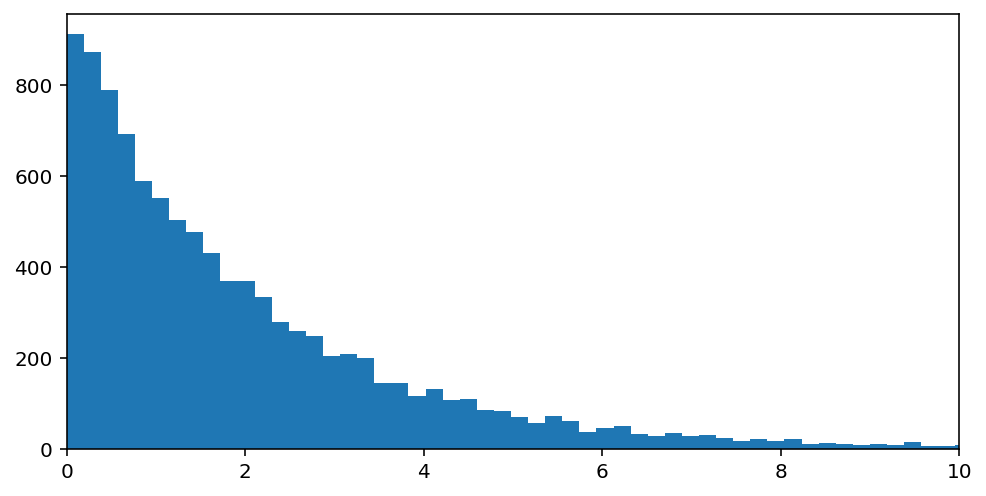

In [2]:
# Generate exponentially-distributed data
yy = np.random.exponential(scale=2.0, size=10**4)

plt.rcParams["figure.figsize"] = (8, 4) # (width, height)
fig, ax = plt.subplots(nrows=1, ncols=1)
ax.hist(yy,bins=100)
ax.set_xlim(left=0,right=10)
plt.show();

In [3]:
# Calculate mean and standard error
mean1 = yy.sum()/len(yy)
mean2 = np.mean(yy)
std1  = np.sqrt(np.square(np.subtract(yy,mean1)).mean())
std2  = np.std(yy)
print(f"mean1 = {mean1:.4f}")
print(f"mean2 = {mean2:.4f}")
print(f"std1  = {std1:.4f}")
print(f"std2  = {std2:.4f}")

mean1 = 1.9725
mean2 = 1.9725
std1  = 1.9874
std2  = 1.9874


np.sqrt(N2)*std_means = 2.0205
np.sqrt(N2)*std_means = 1.9282
np.sqrt(N2)*std_means = 1.9696
np.sqrt(N2)*std_means = 1.9812
np.sqrt(N2)*std_means = 2.0633
np.sqrt(N2)*std_means = 1.9188
np.sqrt(N2)*std_means = 1.9506
np.sqrt(N2)*std_means = 2.0052
np.sqrt(N2)*std_means = 1.9765
np.sqrt(N2)*std_means = 1.9466


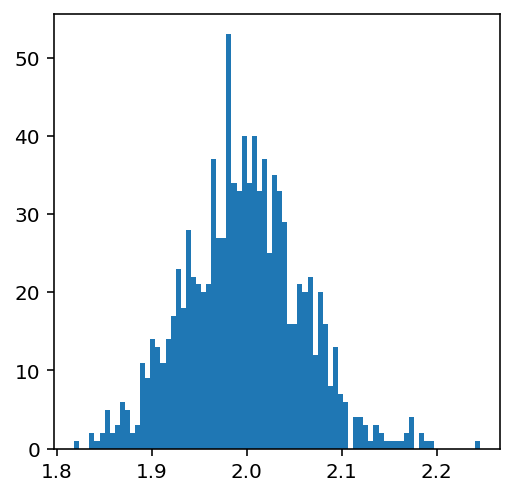

In [4]:
# Using CLT to convert to Normal distribution to estimate the error
# Split N points into N1 groups of N2 points
# Calculate mean for each group
# Estimate error of distribution of means
# Multiply by sqrt(group_size)

N1 = 1000   # N groups
N2 = 1000   # N points in each group
N  = N1*N2 # N = total number of points

for trial in range(10):
    means = []
    for ii in range(N1):
        yy = np.random.exponential(scale=2.0, size=N2)
        means.append(np.mean(yy))

    std_means = np.std(means)
    print(f"np.sqrt(N2)*std_means = {np.sqrt(N2)*std_means:.4f}")
    
plt.rcParams["figure.figsize"] = (4, 4) # (width, height)
fig, ax = plt.subplots(nrows=1, ncols=1)
ax.hist(means, bins=80)
plt.show();

np.sqrt(N2)*std_means = 2.0288
np.sqrt(N2)*std_means = 1.9655
np.sqrt(N2)*std_means = 1.8865
np.sqrt(N2)*std_means = 2.0139
np.sqrt(N2)*std_means = 1.9374
np.sqrt(N2)*std_means = 1.9772
np.sqrt(N2)*std_means = 1.9798
np.sqrt(N2)*std_means = 2.0276
np.sqrt(N2)*std_means = 1.9944
np.sqrt(N2)*std_means = 1.9818


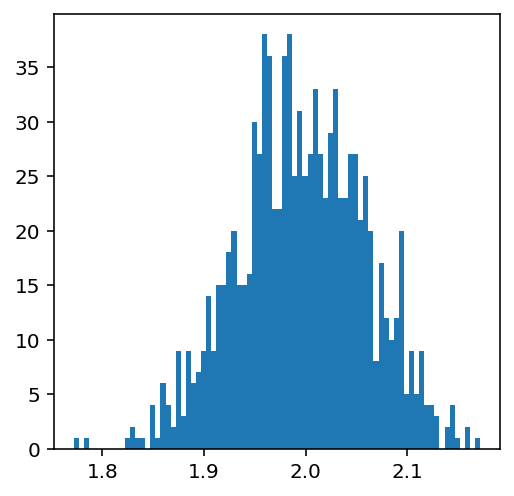

In [5]:
# Using CLT to convert to Normal distribution to estimate the error
# Bootstrap N1 groups of N2 points out of all data points
# Calculate mean for each group
# Estimate error of distribution of means
# Multiply by  sqrt(N2)
N_data = 10**6
data = np.random.exponential(scale=2.0, size=N_data)

N1 = 1000 # N groups
N2 = 1000 # N points in each group
for trial in range(10):
    means = []
    for ii in range(N1):
        yy = np.random.choice(data, replace=True, size=N1)
        means.append(np.mean(yy))

    std_means = np.std(means)
    print(f"np.sqrt(N2)*std_means = {np.sqrt(N2)*std_means:.4f}")
    
plt.rcParams["figure.figsize"] = (4, 4) # (width, height)
fig, ax = plt.subplots(nrows=1, ncols=1)
ax.hist(means, bins=80)
plt.show();